In [26]:
import pandas as pd
from scipy import stats

In [27]:
from cloud_data import load_from_bucket

cleanedData = load_from_bucket("student-wellbeing-effect", 
                               "student_productivity_distraction_dataset_20000.csv")

File downloaded from bucket student-wellbeing-effect


In [28]:
cleanedData.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [29]:
cleanedData.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='str')

Soriting the columns I need

In [30]:
columns_needed = [
    "study_hours_per_day",
    "sleep_hours",
    "exercise_minutes",
    "stress_level",
    "final_grade"
]

In [31]:
needed_data = cleanedData[columns_needed]
needed_data.describe()

,study_hours_per_day,sleep_hours,exercise_minutes,stress_level,final_grade
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,5.254562,6.517799,59.648050,5.478750,70.266409
std,2.742876,2.029784,34.611751,2.866943,17.282277
min,0.500000,3.000000,0.000000,1.000000,40.000000
25%,2.900000,4.770000,30.000000,3.000000,55.460000
50%,5.250000,6.510000,60.000000,5.000000,70.315000
75%,7.640000,8.310000,90.000000,8.000000,85.340000
max,10.000000,10.000000,119.000000,10.000000,99.990000


Making sure there are no missing values

In [32]:
needed_data.isnull().sum()

study_hours_per_day    0
sleep_hours            0
exercise_minutes       0
stress_level           0
final_grade            0
dtype: int64

As the data is complete I can now construct the wellbeing index

Normalising values

In [33]:
needed_data['exercise_norm'] = (needed_data['exercise_minutes'] - needed_data['exercise_minutes'].min()) / \
                                (needed_data['exercise_minutes'].max() - needed_data['exercise_minutes'].min())

needed_data['sleep_norm'] = (needed_data['sleep_hours'] - needed_data['sleep_hours'].min()) / \
                             (needed_data['sleep_hours'].max() - needed_data['sleep_hours'].min())


Stress is inverted as it can be seen as something that would affect the wellbeing of an individual negativley:

In [34]:
needed_data['stress_norm'] = 1 - (needed_data['stress_level'] - needed_data['stress_level'].min()) / \
                                  (needed_data['stress_level'].max() - needed_data['stress_level'].min())

In [35]:
needed_data['wellbeing_score'] = (
    needed_data['exercise_norm'] +
    needed_data['sleep_norm'] +
    needed_data['stress_norm']
) / 3

Addidng the wellbeing score to the data set

In [36]:
cleanedData['wellbeing_score'] = needed_data['wellbeing_score']

In [37]:
needed_data.head(10)

,study_hours_per_day,sleep_hours,exercise_minutes,stress_level,final_grade,exercise_norm,sleep_norm,stress_norm,wellbeing_score
0,4.35,3.63,111,10,81.87,0.932773,0.090000,0.000000,0.340924
1,6.14,6.58,28,10,60.90,0.235294,0.511429,0.000000,0.248908
2,4.98,3.26,102,2,86.22,0.857143,0.037143,0.888889,0.594392
3,3.19,4.58,28,6,71.77,0.235294,0.225714,0.444444,0.301818
4,7.67,6.21,105,6,90.13,0.882353,0.458571,0.444444,0.595123
5,7.18,3.52,12,10,59.48,0.100840,0.074286,0.000000,0.058375
6,9.06,6.36,28,8,62.71,0.235294,0.480000,0.222222,0.312505
7,6.37,4.86,103,6,52.22,0.865546,0.265714,0.444444,0.525235
8,4.19,4.87,42,3,76.15,0.352941,0.267143,0.777778,0.465954
9,7.28,9.56,107,10,88.53,0.899160,0.937143,0.000000,0.612101


Making sure all values are between 0-1

In [38]:
needed_data['wellbeing_score'].describe()

count    20000.000000
mean         0.502049
std          0.173043
min          0.005238
25%          0.380437
50%          0.501872
75%          0.624452
max          0.994818
Name: wellbeing_score, dtype: float64

Now that the wellbeing score is calculated & added to the data set I can calculte the effect of hours studied and a students wellbeing on their final grade. To do so I will use the Pearson Correlation formula

Pearson Correlation: Study Hours vs Final Grade

In [39]:
corr_study, p_study = stats.pearsonr(cleanedData['study_hours_per_day'], cleanedData['final_grade'])

print(f"Study Hours vs Final Grade")
print(f"Correlation: {corr_study:.4f}")
print(f"P-value:     {p_study:.4f}")

Study Hours vs Final Grade
Correlation: -0.0122
P-value:     0.0843


Pearson Correlation: Wellbeing Score vs Final Grade

In [40]:
corr_wellbeing, p_wellbeing = stats.pearsonr(cleanedData['wellbeing_score'], cleanedData['final_grade'])

print(f"Wellbeing Score vs Final Grade")
print(f"Correlation: {corr_wellbeing:.4f}")
print(f"P-value:     {p_wellbeing:.4f}")

Wellbeing Score vs Final Grade
Correlation: 0.0119
P-value:     0.0928


Side by side comparison

In [41]:
print("=" * 40)
print(f"{'Predictor':<25} {'Correlation':>11} {'P-value':>8}")
print("=" * 40)
print(f"{'study_hours_per_day':<25} {corr_study:>11.4f} {p_study:>8.4f}")
print(f"{'wellbeing_score':<25} {corr_wellbeing:>11.4f} {p_wellbeing:>8.4f}")
print("=" * 40)

Predictor                 Correlation  P-value
study_hours_per_day           -0.0122   0.0843
wellbeing_score                0.0119   0.0928


Wellbeing seems to have a larger influence on the final grade than hours studied does!

That being said both seem to be close to zero.. Therefore I'll check whether any value seems to directly affect the final grade

In [42]:
all_correlations = cleanedData.corr(numeric_only=True)['final_grade'].sort_values(ascending=False)
print(all_correlations)


final_grade              1.000000
coffee_intake_mg         0.015326
wellbeing_score          0.011884
sleep_hours              0.010543
student_id               0.007043
focus_score              0.004630
assignments_completed    0.003894
gaming_hours             0.002544
productivity_score       0.001954
youtube_hours            0.001579
social_media_hours      -0.000117
age                     -0.000857
exercise_minutes        -0.002677
breaks_per_day          -0.003690
attendance_percentage   -0.005270
phone_usage_hours       -0.012136
study_hours_per_day     -0.012208
stress_level            -0.012216
Name: final_grade, dtype: float64


Since all values seem close to zero, meaning the correlation between them and the final grade is almost none, I have to assume that the data set is sythetically generated.

Data Visualisation:

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

Scatter Plot: Wellbeing Score vs Final Grade

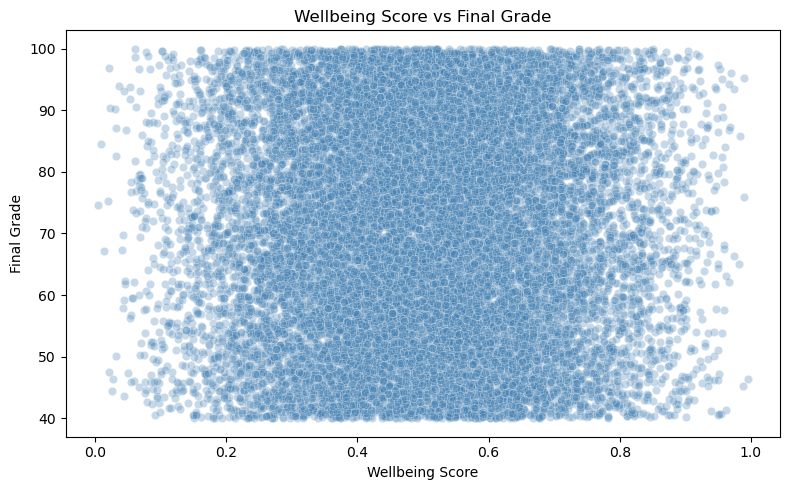

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cleanedData, x='wellbeing_score', y='final_grade', alpha=0.3, color='steelblue')
plt.title('Wellbeing Score vs Final Grade')
plt.xlabel('Wellbeing Score')
plt.ylabel('Final Grade')
plt.tight_layout()
plt.savefig('scatter_wellbeing.png')
plt.show()

Scatter Plot: Study Hours vs Final Grade

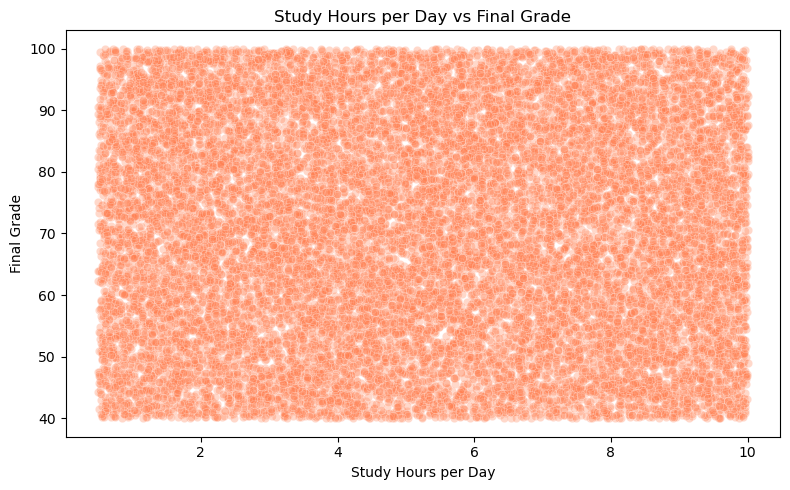

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cleanedData, x='study_hours_per_day', y='final_grade', alpha=0.3, color='coral')
plt.title('Study Hours per Day vs Final Grade')
plt.xlabel('Study Hours per Day')
plt.ylabel('Final Grade')
plt.tight_layout()
plt.savefig('scatter_studyhours.png')
plt.show()

Correlation Heatmap: All Five Key Variables

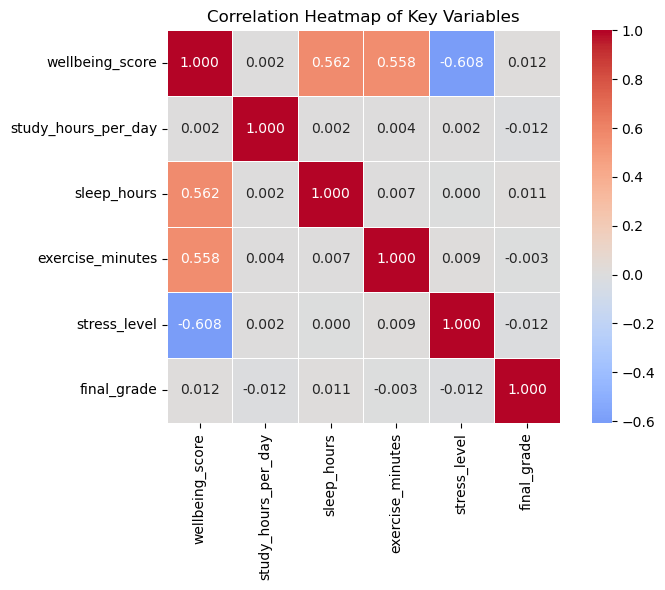

In [46]:
key_vars = needed_data[['wellbeing_score', 'study_hours_per_day', 'sleep_hours', 
                          'exercise_minutes', 'stress_level', 'final_grade']]

plt.figure(figsize=(8, 6))
sns.heatmap(key_vars.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

Bar Chart: Low / Medium / High Wellbeing Groups vs Average Final Grade

/var/folders/sf/n2tp64jj60q75b0d0m06qzmr0000gn/T/ipykernel_79490/3894392516.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_avg, x='wellbeing_group', y='final_grade',


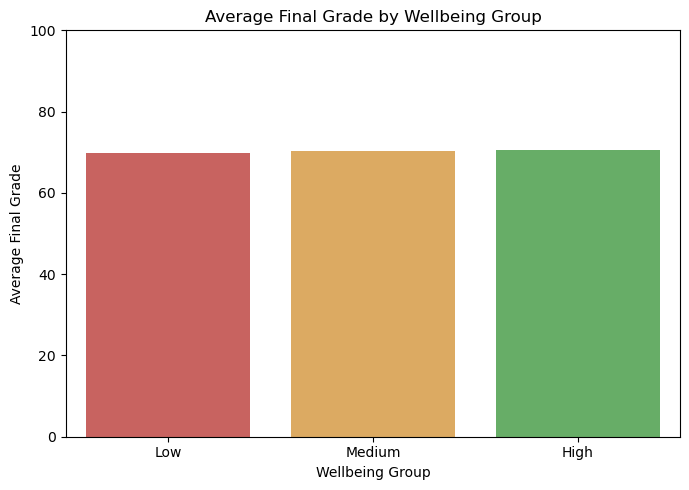

In [47]:
needed_data['wellbeing_group'] = pd.cut(
    needed_data['wellbeing_score'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

group_avg = needed_data.groupby('wellbeing_group', observed=True)['final_grade'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=group_avg, x='wellbeing_group', y='final_grade', 
            palette=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.title('Average Final Grade by Wellbeing Group')
plt.xlabel('Wellbeing Group')
plt.ylabel('Average Final Grade')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('barchart_wellbeing_groups.png')
plt.show()

Now that my data is visualised I'd like to upload it to my bucket and not just save the files locally 

In [49]:
from cloud_data import upload_file_to_bucket

charts = [
    'scatter_wellbeing.png',
    'scatter_studyhours.png',
    'heatmap.png',
    'barchart_wellbeing_groups.png'
]

for chart in charts:
    upload_file_to_bucket(chart)

scatter_wellbeing.png uploaded to bucket student-wellbeing-effect
scatter_studyhours.png uploaded to bucket student-wellbeing-effect
heatmap.png uploaded to bucket student-wellbeing-effect
barchart_wellbeing_groups.png uploaded to bucket student-wellbeing-effect
